In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\C9IN\Desktop\Mental_Health\02_Dataset\01_Data.csv")

1.Rename Columns

In [2]:
print(df.columns)

Index(['Name', 'Age', 'Marital Status', 'Education Level',
       'Number of Children', 'Smoking Status', 'Physical Activity Level',
       'Employment Status', 'Income', 'Alcohol Consumption', 'Dietary Habits',
       'Sleep Patterns', 'History of Mental Illness',
       'History of Substance Abuse', 'Family History of Depression',
       'Chronic Medical Conditions'],
      dtype='object')


In [3]:
df.columns = df.columns.str.replace(" ", "_")
print(df.columns)

Index(['Name', 'Age', 'Marital_Status', 'Education_Level',
       'Number_of_Children', 'Smoking_Status', 'Physical_Activity_Level',
       'Employment_Status', 'Income', 'Alcohol_Consumption', 'Dietary_Habits',
       'Sleep_Patterns', 'History_of_Mental_Illness',
       'History_of_Substance_Abuse', 'Family_History_of_Depression',
       'Chronic_Medical_Conditions'],
      dtype='object')


2.Handle Missing Values

In [4]:
df.isnull().sum()

Name                             0
Age                              9
Marital_Status                   7
Education_Level                 27
Number_of_Children               0
Smoking_Status                  27
Physical_Activity_Level          0
Employment_Status               17
Income                           0
Alcohol_Consumption             24
Dietary_Habits                   0
Sleep_Patterns                   0
History_of_Mental_Illness        0
History_of_Substance_Abuse       0
Family_History_of_Depression     0
Chronic_Medical_Conditions       0
dtype: int64

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

cols = ['Marital_Status', 'Education_Level', 'Smoking_Status', 
                    'Employment_Status', 'Alcohol_Consumption']

for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
df.isnull().sum()

Name                            0
Age                             0
Marital_Status                  0
Education_Level                 0
Number_of_Children              0
Smoking_Status                  0
Physical_Activity_Level         0
Employment_Status               0
Income                          0
Alcohol_Consumption             0
Dietary_Habits                  0
Sleep_Patterns                  0
History_of_Mental_Illness       0
History_of_Substance_Abuse      0
Family_History_of_Depression    0
Chronic_Medical_Conditions      0
dtype: int64

3.Remove Duplicate Data

In [7]:
df.duplicated().sum()

np.int64(4)

In [8]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

4.Fix Incorrect Data Types

In [9]:
df["Age"].dtype

dtype('float64')

In [10]:
df["Age"] = df["Age"].astype(int)
df["Age"].dtype

dtype('int64')

In [11]:
df["Income"].dtype

dtype('O')

In [12]:
df["Income"] = df["Income"].str.replace("$", "", regex=False)
df["Income"] = df["Income"].str.replace(",", "", regex=False)

In [13]:
df["Income"] = pd.to_numeric(df["Income"])
df["Income"].dtype

dtype('float64')

5. Remove Irrelevant Columns

In [14]:
df=df.drop(columns=["Name"])

In [15]:
print(df.columns)

Index(['Age', 'Marital_Status', 'Education_Level', 'Number_of_Children',
       'Smoking_Status', 'Physical_Activity_Level', 'Employment_Status',
       'Income', 'Alcohol_Consumption', 'Dietary_Habits', 'Sleep_Patterns',
       'History_of_Mental_Illness', 'History_of_Substance_Abuse',
       'Family_History_of_Depression', 'Chronic_Medical_Conditions'],
      dtype='object')


6.Remove negative

In [16]:
import numpy as np
print("Number of negative = ",(df["Income"] < 0).sum())
df.loc[df["Income"] < 0, "Income"] = np.nan
df["Income"] = df["Income"].fillna(df["Income"].mean())
print("Number of negative = ",(df["Income"] < 0).sum())

Number of negative =  1
Number of negative =  0


7.Detect and Handle Outliers

<Axes: ylabel='Income'>

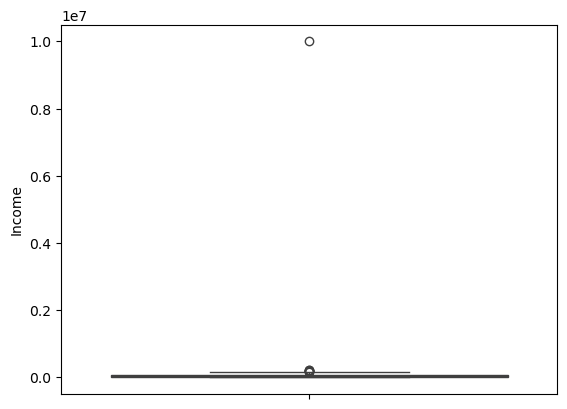

In [17]:
import seaborn as sns
sns.boxplot(df["Income"])

<Axes: ylabel='Income'>

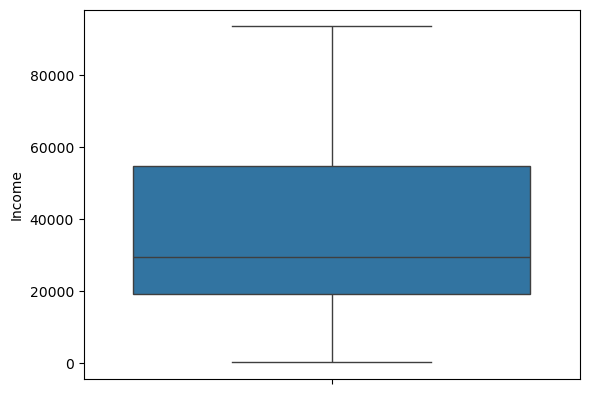

In [28]:
df = df[df["Income"] < df["Income"].quantile(0.95)]
import seaborn as sns
sns.boxplot(df["Income"])


{'whiskers': [<matplotlib.lines.Line2D at 0x179b4ab5bd0>,
 'caps': [<matplotlib.lines.Line2D at 0x179b4ab5e50>,
 'boxes': [<matplotlib.lines.Line2D at 0x179b4ab5a90>],
 'medians': [<matplotlib.lines.Line2D at 0x179b4ab60d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x179b4ab6210>],
 'means': []}

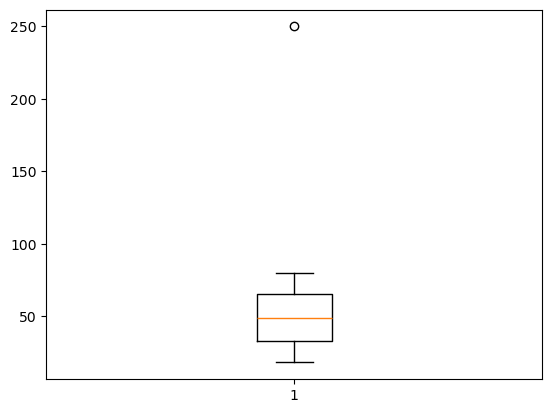

In [19]:
import matplotlib.pyplot as plt
plt.boxplot(df["Age"])

{'whiskers': [<matplotlib.lines.Line2D at 0x179b41d3890>,
 'caps': [<matplotlib.lines.Line2D at 0x179b4b34550>,
 'boxes': [<matplotlib.lines.Line2D at 0x179b4373c50>],
 'medians': [<matplotlib.lines.Line2D at 0x179b4b347d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x179b4b34910>],
 'means': []}

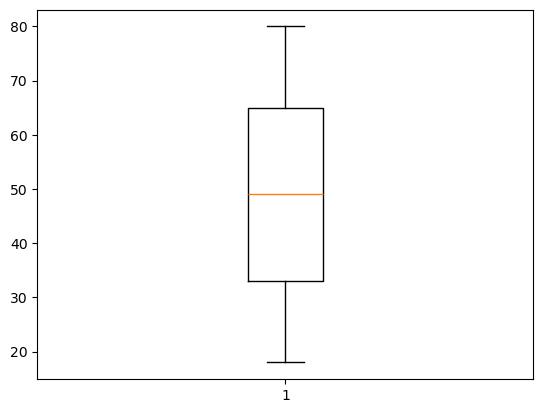

In [20]:
df = df[(df["Age"] >= 0) & (df["Age"] <= 100)]
import matplotlib.pyplot as plt
plt.boxplot(df["Age"])

In [21]:
Q1 = df["Number_of_Children"].quantile(0.25)
Q3 = df["Number_of_Children"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Number_of_Children"] < lower_bound) | 
              (df["Number_of_Children"] > upper_bound)]

print(outliers["Number_of_Children"])

504    50
Name: Number_of_Children, dtype: int64


In [29]:
df = df[df["Number_of_Children"] <= 5]
outliers = df[(df["Number_of_Children"] < lower_bound) | 
              (df["Number_of_Children"] > upper_bound)]

print(outliers["Number_of_Children"])

Series([], Name: Number_of_Children, dtype: int64)


8.Remove space from each columns

In [30]:
for col in df.select_dtypes(include="object").columns:
    try:
        df[col] = df[col].str.strip()
    except:
        print(f"Error in column: {col}")

9.Validate Data

In [31]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 408 entries, 0 to 508
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           408 non-null    int64  
 1   Marital_Status                408 non-null    object 
 2   Education_Level               408 non-null    object 
 3   Number_of_Children            408 non-null    int64  
 4   Smoking_Status                408 non-null    object 
 5   Physical_Activity_Level       408 non-null    object 
 6   Employment_Status             408 non-null    object 
 7   Income                        408 non-null    float64
 8   Alcohol_Consumption           408 non-null    object 
 9   Dietary_Habits                408 non-null    object 
 10  Sleep_Patterns                408 non-null    object 
 11  History_of_Mental_Illness     408 non-null    object 
 12  History_of_Substance_Abuse    408 non-null    object 
 13  Family_His

Age                             0
Marital_Status                  0
Education_Level                 0
Number_of_Children              0
Smoking_Status                  0
Physical_Activity_Level         0
Employment_Status               0
Income                          0
Alcohol_Consumption             0
Dietary_Habits                  0
Sleep_Patterns                  0
History_of_Mental_Illness       0
History_of_Substance_Abuse      0
Family_History_of_Depression    0
Chronic_Medical_Conditions      0
Z_score                         0
dtype: int64

10.Save the Clean Dataset

In [25]:
df.to_csv("../02_Dataset/02_clean_dataset.csv", index=False)